In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
from src.utils import get_isnull_ratio

In [60]:
df = pd.read_csv('data/Train.csv')

In [61]:
get_isnull_ratio(df)

ZONE2             0.936481
ZONE1             0.921208
TIGO              0.598880
DATA_VOLUME       0.492298
TOP_PACK          0.419022
FREQ_TOP_PACK     0.419022
ORANGE            0.415612
REGION            0.394280
ON_NET            0.365208
MONTANT           0.351310
FREQUENCE_RECH    0.351310
FREQUENCE         0.337062
ARPU_SEGMENT      0.337062
REVENUE           0.337062
user_id           0.000000
TENURE            0.000000
MRG               0.000000
REGULARITY        0.000000
CHURN             0.000000
dtype: float64

In [62]:
numerical_cols = ['MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE',
       'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'ZONE1', 'ZONE2',
       'REGULARITY', 'FREQ_TOP_PACK']

y_column = ["CHURN"]

cat_cols = ["TENURE"]

drop_cols = ['user_id', 'MRG', 'TOP_PACK']

df = df.drop(columns=drop_cols)


### Creating splits to find best params:

In [63]:
X, y = df.drop(columns=["CHURN"]), df["CHURN"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Imputing NaN values:

In [64]:
numerical_cols_to_fill = [
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT', 
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO', 
    'ZONE1',
    'ZONE2',
    'FREQ_TOP_PACK'
]

cat_cols_to_fill = [
    "REGION"
]

### Imputing with just mean values:

In [65]:
from src.imputers import fill_nulls_with_mean, impute_with_boosting

In [66]:
X_train_mean_imputed = fill_nulls_with_mean(
    df_to_fill=X_train,
    df_to_compute_mean=X_train,
    numerical_columns=numerical_cols_to_fill,
    categorical_columns=cat_cols_to_fill
)

X_val_mean_imputed = fill_nulls_with_mean(
    df_to_fill=X_val,
    df_to_compute_mean=X_train,
    numerical_columns=numerical_cols_to_fill,
    categorical_columns=cat_cols_to_fill
)

### Imputing with boosting:

In [67]:
model_params = {
    # 'iterations': 500, 'learning_rate': 0.1,
    # 'auto_class_weights': 'Balanced'
}

print("Imputing 'REGION' ")
X_train_catboost_imputed, X_val_catboost_imputed, model = impute_with_boosting(
    df_to_train_on=X_train,
    df_train_to_impute=X_train,
    df_test_to_impute=X_val,
    column_name="REGION",
    column_type="categorical",
    feature_columns=None,
    model_params=model_params,
    use_gpu=True,
    verbose=False,
)


for col_name in numerical_cols_to_fill:
    print(f"Imputing '{col_name}' ")
    X_train_catboost_imputed, X_val_catboost_imputed, model = impute_with_boosting(
        df_to_train_on=X_train_catboost_imputed,
        df_train_to_impute=X_train_catboost_imputed,
        df_test_to_impute=X_val_catboost_imputed,
        column_name=col_name,
        column_type="numerical",
        feature_columns=numerical_cols_to_fill,
        model_params=model_params,
        use_gpu=True,
        verbose=False,
    )

Imputing 'REGION' 
Training accuracy: 0.4210
Imputing 'MONTANT' 
Training MAE: 95.9096, RMSE: 498.2354
Imputing 'FREQUENCE_RECH' 
Training MAE: 0.0004, RMSE: 0.0007
Imputing 'REVENUE' 
Training MAE: 114.5604, RMSE: 503.5219
Imputing 'ARPU_SEGMENT' 
Training MAE: 38.4107, RMSE: 169.0215
Imputing 'FREQUENCE' 
Training MAE: 0.0000, RMSE: 0.0000
Imputing 'DATA_VOLUME' 
Training MAE: 259.8362, RMSE: 5833.1800
Imputing 'ON_NET' 
Training MAE: 13.2794, RMSE: 117.8914
Imputing 'ORANGE' 
Training MAE: 3.2748, RMSE: 23.5799
Imputing 'TIGO' 
Training MAE: 0.5580, RMSE: 4.6467
Imputing 'ZONE1' 
Training MAE: 0.1045, RMSE: 0.3501
Imputing 'ZONE2' 
Training MAE: 0.0831, RMSE: 0.2100
Imputing 'FREQ_TOP_PACK' 
Training MAE: 0.0092, RMSE: 0.0183


---
## CatBoost + Optuna:

In [102]:
from src.catboost import optimize_catboost_optuna

In [ ]:
cat_features = ["REGION", "TENURE"]

study_catboost_imputed = optimize_catboost_optuna(
    X_train_catboost_imputed, X_val_catboost_imputed, y_train, y_val,
    score_metric="f1",
    cat_features=cat_features,
    n_trials=10,
    use_gpu=True,
)

[I 2025-10-22 13:01:14,400] A new study created in memory with name: catboost_optimization


  0%|          | 0/1 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU


Using f1 as score metric
[I 2025-10-22 13:01:24,582] Trial 0 finished with value: 0.6645124207251984 and parameters: {'iterations': 1191, 'learning_rate': 0.10753452055062625, 'depth': 6, 'l2_leaf_reg': 0.35096067637684536, 'scale_pos_weight': 3.045238759962844}. Best is trial 0 with value: 0.6645124207251984.
🏆 New Best Trial 0; Score: 0.66451


In [104]:
study_mean_imputed = optimize_catboost_optuna(
    X_train_mean_imputed, X_val_mean_imputed, y_train, y_val,
    score_metric="f1",
    cat_features=cat_features,
    n_trials=10,
    use_gpu=True,
)

[I 2025-10-22 13:01:24,689] A new study created in memory with name: catboost_optimization


  0%|          | 0/10 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU


[W 2025-10-22 13:01:34,445] Trial 0 failed with parameters: {'iterations': 1297, 'learning_rate': 0.1133511961977419, 'depth': 11, 'l2_leaf_reg': 0.42013961270359, 'scale_pos_weight': 5.163893722866364} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/home/jovyan/avarlamov/skoltech-ds-project/.venv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/home/jovyan/avarlamov/skoltech-ds-project/src/catboost.py", line 78, in <lambda>
    lambda trial: objective(trial, X_train, X_val, y_train, y_val, cat_features, score_metric, use_gpu),
  File "/home/jovyan/avarlamov/skoltech-ds-project/src/catboost.py", line 45, in objective
    model.fit(
  File "/home/jovyan/avarlamov/skoltech-ds-project/.venv/lib/python3.10/site-packages/catboost/core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, No

KeyboardInterrupt: 

In [ ]:
study_catboost_imputed.best_trial.params

{'iterations': 1201,
 'learning_rate': 0.02621148949461745,
 'depth': 7,
 'l2_leaf_reg': 0.10279875565674453,
 'scale_pos_weight': 5.871951050484503}

In [ ]:
study_mean_imputed.best_trial.params

{'iterations': 734,
 'learning_rate': 0.19577944441963643,
 'depth': 8,
 'l2_leaf_reg': 1.2637608025040634,
 'scale_pos_weight': 3.6691689190213843}

## Measure metrics on K-Fold Cross-Validation:

- It is important to do Cross-Validation correctly with no data leakage from NaN imputation:
    - We train imputers on K-1 train folds and apply them on K-th test fold

In [ ]:
from src.catboost import cross_validate_catboost

In [ ]:
cv_result_catboost_imputed = cross_validate_catboost(
    X, y,
    best_params=study_catboost_imputed.best_trial.params,
    imputation_method="catboost",
    numerical_cols_to_fill=numerical_cols_to_fill,
    cat_cols_to_fill=cat_cols_to_fill,
    cat_features=cat_features,
    use_gpu=True,
    cv=5,
    random_state=42,
    verbose=200
)

Cross-Validating, Fold:...:   0%|          | 0/5 [00:00<?, ?it/s]

Imputing 'REGION' 
Training accuracy: 0.4209
Imputing 'MONTANT' 
Training MAE: 105.1584, RMSE: 536.8541
Imputing 'FREQUENCE_RECH' 
Training MAE: 0.0004, RMSE: 0.0008
Imputing 'REVENUE' 
Training MAE: 117.2534, RMSE: 509.4604
Imputing 'ARPU_SEGMENT' 
Training MAE: 38.9063, RMSE: 168.7613
Imputing 'FREQUENCE' 
Training MAE: 0.0000, RMSE: 0.0000
Imputing 'DATA_VOLUME' 
Training MAE: 267.4713, RMSE: 6057.1420
Imputing 'ON_NET' 
Training MAE: 13.6169, RMSE: 123.2458
Imputing 'ORANGE' 
Training MAE: 3.2215, RMSE: 22.9801
Imputing 'TIGO' 
Training MAE: 0.4929, RMSE: 3.9140
Imputing 'ZONE1' 
Training MAE: 0.1184, RMSE: 0.3892
Imputing 'ZONE2' 
Training MAE: 0.0825, RMSE: 0.2144
Imputing 'FREQ_TOP_PACK' 
Training MAE: 0.0089, RMSE: 0.0184
0:	learn: 0.6713503	total: 21.7ms	remaining: 26.1s
200:	learn: 0.3501977	total: 4.25s	remaining: 21.1s
400:	learn: 0.3478447	total: 8.5s	remaining: 17s
600:	learn: 0.3464166	total: 12.8s	remaining: 12.8s
800:	learn: 0.3453219	total: 17.2s	remaining: 8.59s
1000

In [ ]:
def print_cv_result(cv_result):
    for metric in cv_result["metrics_mean"]:
        print(f"{metric}: {cv_result['metrics_mean'][metric]:.4f} ± {cv_result['metrics_std'][metric]:.4f}")

print_cv_result(cv_result_catboost_imputed)

ACC: 0.8018 ± 0.0006
F1: 0.6339 ± 0.0008
BAL-ACC: 0.8453 ± 0.0006
ROC-AUC: 0.9165 ± 0.0005
ROC-AUC@0.01FPR: 0.5377 ± 0.0005


In [ ]:
cv_result_mean_imputed = cross_validate_catboost(
    X, y,
    best_params=study_mean_imputed.best_trial.params,
    imputation_method="mean",
    numerical_cols_to_fill=numerical_cols_to_fill,
    cat_cols_to_fill=cat_cols_to_fill,
    cat_features=cat_features,
    use_gpu=True,
    cv=5,
    random_state=42,
    verbose=200
)

print_cv_result(cv_result_mean_imputed)

Cross-Validating, Fold:...:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 0.5394436	total: 29.3ms	remaining: 21.5s
200:	learn: 0.3479434	total: 5.77s	remaining: 15.3s
400:	learn: 0.3429283	total: 11.5s	remaining: 9.56s
600:	learn: 0.3385718	total: 17.3s	remaining: 3.82s
733:	learn: 0.3358779	total: 21.1s	remaining: 0us
0:	learn: 0.5399248	total: 30.4ms	remaining: 22.3s
200:	learn: 0.3483374	total: 5.81s	remaining: 15.4s
400:	learn: 0.3430593	total: 11.6s	remaining: 9.64s
600:	learn: 0.3387001	total: 17.5s	remaining: 3.87s
733:	learn: 0.3360235	total: 21.3s	remaining: 0us
0:	learn: 0.5393432	total: 29ms	remaining: 21.3s
200:	learn: 0.3478496	total: 5.77s	remaining: 15.3s
400:	learn: 0.3427021	total: 11.5s	remaining: 9.57s
600:	learn: 0.3383560	total: 17.3s	remaining: 3.83s
733:	learn: 0.3357643	total: 21.2s	remaining: 0us
0:	learn: 0.5401162	total: 29.4ms	remaining: 21.6s
200:	learn: 0.3484288	total: 5.79s	remaining: 15.3s
400:	learn: 0.3433861	total: 11.6s	remaining: 9.6s
600:	learn: 0.3390579	total: 17.4s	remaining: 3.84s
733:	learn: 0.3365366	tot

## Feature Importances:

0:	learn: 0.6711532	total: 22.9ms	remaining: 27.5s
200:	learn: 0.3508101	total: 4.39s	remaining: 21.8s
400:	learn: 0.3483198	total: 8.75s	remaining: 17.5s
600:	learn: 0.3467827	total: 13.1s	remaining: 13.1s
800:	learn: 0.3456233	total: 17.5s	remaining: 8.72s
1000:	learn: 0.3446563	total: 21.8s	remaining: 4.35s
1200:	learn: 0.3437851	total: 26s	remaining: 0us


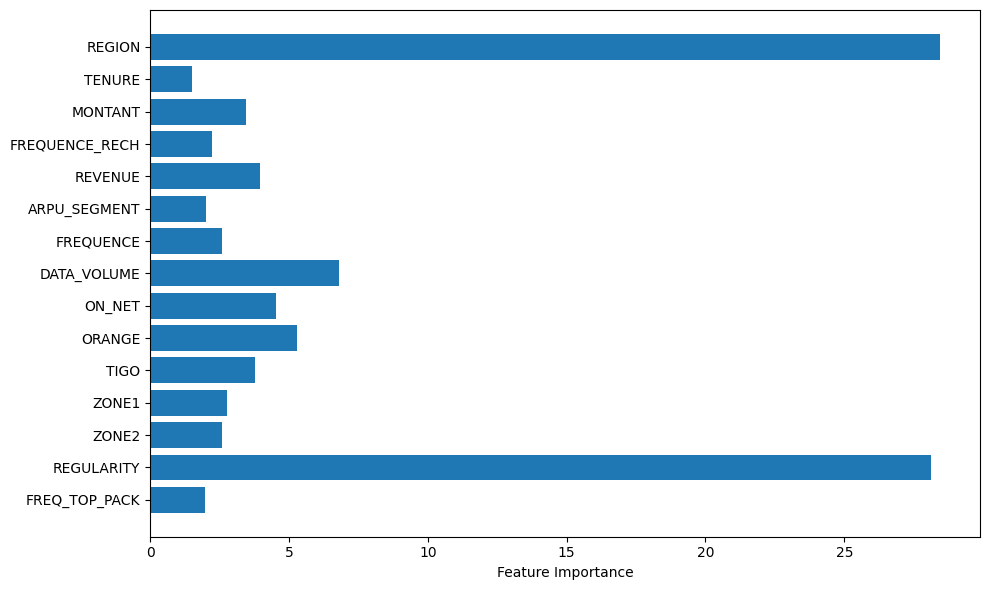

In [ ]:
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

def plot_feature_importances(model, figsize=(10, 6)):
    feature_names = model.feature_names_
    feature_importances = model.feature_importances_
    
    plt.figure(figsize=figsize)
    plt.barh(feature_names, feature_importances)
    plt.xlabel('Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

model_catboost_imputed = CatBoostClassifier(task_type="GPU", devices="0", **study_catboost_imputed.best_trial.params, verbose=200)
model_catboost_imputed.fit(X_train_catboost_imputed, y_train, cat_features=cat_features)
plot_feature_importances(model_catboost_imputed)

0:	learn: 0.5397883	total: 30.4ms	remaining: 22.3s
200:	learn: 0.3481423	total: 5.88s	remaining: 15.6s
400:	learn: 0.3431671	total: 11.8s	remaining: 9.8s
600:	learn: 0.3388849	total: 17.7s	remaining: 3.91s
733:	learn: 0.3362154	total: 21.6s	remaining: 0us


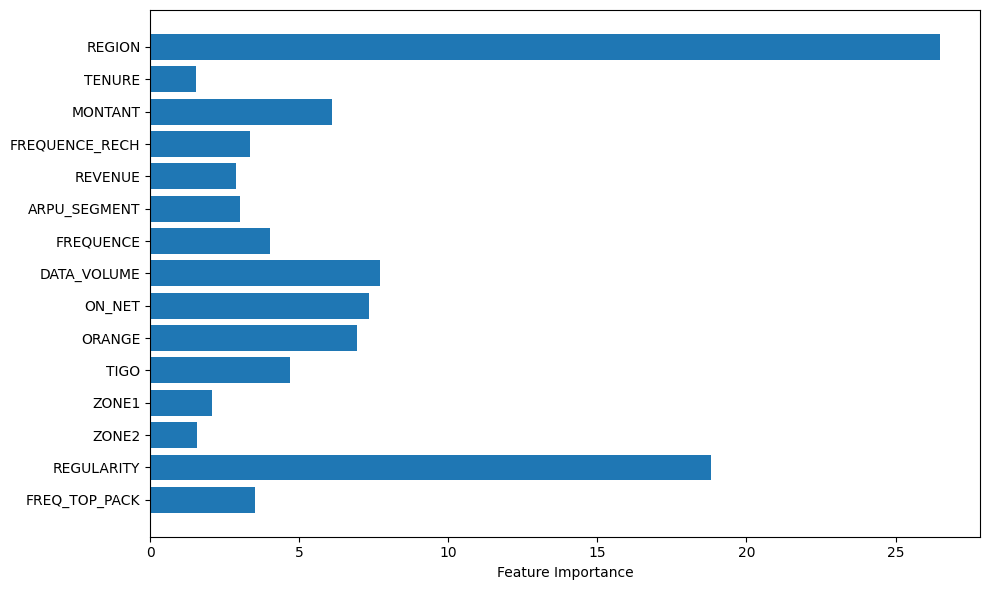

In [ ]:
model_catboost_imputed = CatBoostClassifier(task_type="GPU", devices="0", **study_mean_imputed.best_trial.params, verbose=200)
model_catboost_imputed.fit(X_train_mean_imputed, y_train, cat_features=cat_features)
plot_feature_importances(model_catboost_imputed)

---
## Results:

- Baseline: 0.500
- CatBoost with Catboost Impute + Optuna Hyperparams search: 0.847